(Surface-ADR)=
# Surface ADR

This time we consider an equation posed on a surface
\begin{equation*}
\partial_t u +
 \nabla_\Gamma \cdot(\vec{b}_\Gamma u - d \nabla_\Gamma u) + cu = f
\end{equation*}
The differential symbols are $\nabla_\Gamma\cdot, \nabla_\Gamma$ are thus the tangential divergence and gradient.


The steps to follow are the same as seen above, we just have to use the keyword `VorB = BND` in the constructor.\
As a side comment, we also have to make sure that the advection field $\vec{b}_\Gamma$ is actually tangential to the surface.


Below we begin with an example of a surface with no boundary.

In [1]:
from ngsolve import *
from cosmos.utils.generate_surface_meshes import generate_circle
from cosmos.solvers.base_problem import UnsteadyProblem
from cosmos.solvers.adr import ADRSolver
from cosmos.utils.manufactured_solution_tools import gradient
from ngsolve.webgui import Draw



mesh, _ = generate_circle(maxh = 0.1)

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = UnsteadyProblem(mesh=mesh, t=t, dt = dt, T = T)

solver = ADRSolver(linear = True)
simulation.attach_solver(solver)

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
d = 1+t
c = cos(x)
b = CF((-y,x))
normal = CF((x,y))/Norm(CF((x,y)))
P = Id(2) - OuterProduct(normal, normal)
flux1 = (b*u_ex).Compile()
flux2 = (- d*gradient(u_ex, P)).Compile()
flux = flux1 + flux2
rhs = (u_ex.Diff(t) + Trace(gradient(flux, P)) + c*u_ex).Compile()


solver.AddSpecie(VorB = BND,
            rhs = rhs,
            advection = b,
            diffusion = d,
            reaction = c,
            u0 = u_ex)
    
simulation.run()

print('Computed solution')
solver.draw_solution()
print('Exact solution')
Draw(u_ex, mesh)


Running Simulation...: 100%|██████████████| 10/10 [00:00<00:00, 348.73it/s]

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

We can see that the mesh used has volume elements, but the software automatically handles that and only works on the surface.
The plotting, saving and the error computation also take care of transporting the solution on a volume mesh if needed.

To note:
- the abvection field $\vec{b}$ needs to be tangential for a correct execution
- trying to add a `VOL` equation to a mesh without volume elements will result in an error

In this cae too we can plot the error between the computed and the exact solution

[0.0011637555255223312, 0.010247665243466098, 0.01371101567358513, 0.0149686120207649, 0.015295236399690248, 0.015134898092993374, 0.014657862038219834, 0.01393793019183814, 0.013015738330177728, 0.011921895071886386, 0.010684936027015805]


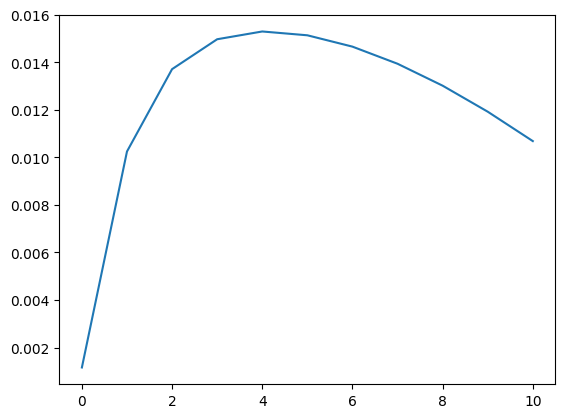

In [2]:
err = solver.compute_error(u_ex, 'L2')
print(err)

import matplotlib.pyplot as plt
plt.plot(err)

Let's try now a case with an open boundary, such as an half sphere. In this case, both Dirichlet and Neumann boundary conditions can be applied, as seen for the bulk case

In [3]:

from ngsolve import *
from cosmos.utils.generate_surface_meshes import generate_half_sphere
from cosmos.solvers.base_problem import UnsteadyProblem
from cosmos.solvers.adr import ADRSolver
from cosmos.utils.manufactured_solution_tools import gradient
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
import numpy as np

bc = 'dir'

mesh, _ = generate_half_sphere(maxh = 0.1)

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = UnsteadyProblem(mesh=mesh, t=t, dt = dt, T = T)

solver = ADRSolver(linear = True)
simulation.attach_solver(solver)

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
normal = CF((x,y,z))/Norm(CF((x,y,z)))
P = Id(3) - OuterProduct(normal, normal)
d = 1 + x**2
c = cos(x)
b = P*CF((-z,0,x))
flux1 = (b*u_ex).Compile()
flux2 = (- d*gradient(u_ex, P)).Compile()
flux = flux1 + flux2
rhs = (u_ex.Diff(t) + Trace(gradient(flux, P)) + c*u_ex).Compile()
neu_b = {'bottom': flux1}
neu_d = {'bottom': flux2}
dir_d = {'bottom': u_ex}
dir_b = {'bottom': u_ex}

if bc == 'dir':
    solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                dir_d = dir_d,
                dir_b = dir_b)
elif bc == 'neu':
    solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                neu_d = neu_d,
                neu_b = neu_b)
    
simulation.run()

print('Computed solution')
solver.draw_solution()
print('Exact solution')
Draw(u_ex, mesh)

Running Simulation...: 100%|███████████████| 10/10 [00:00<00:00, 45.29it/s]

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

The same for a 1D line

Running Simulation...: 100%|████████████| 100/100 [00:00<00:00, 348.63it/s]

[0.00322078643599198, 0.4513530649796229, 0.7051597108401514, 0.8801975845947743, 1.009769078956527, 1.105751248849712, 1.1727649099329958, 1.212981967683684, 1.2278982049450473, 1.2189547933500546, 1.1877248604279336, 1.135949283675016, 1.0655334494446658, 0.9785509430568782, 0.8772819919093527, 0.7643269208205012, 0.6428942356305775, 0.5175573305566261, 0.3964315019703381, 0.29759557504479145, 0.2593690829625328, 0.31006611727806527, 0.4190845768059918, 0.5512283601441073, 0.6904235214028538, 0.8294545440874317, 0.964325612961794, 1.0923536411531205, 1.2114955890962198, 1.3200857318716392, 1.416724131374237, 1.500226864082139, 1.5696035712464873, 1.6240477414474288, 1.6629330180603887, 1.6858122366074253, 1.6924174974435675, 1.6826603972399903, 1.656632012708744, 1.6146025569079256, 1.5570209321384807, 1.4845147901948412, 1.3978923334905802, 1.2981482465394327, 1.1864785032365572, 1.064313988697277, 0.9333952723772473, 0.7959432002479423, 0.6550729928352057, 0.5158944610890923, 0.388

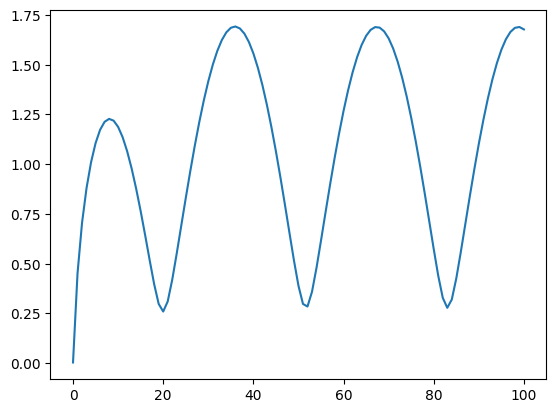

In [4]:


from ngsolve import *
from cosmos.utils.generate_surface_meshes import generate_arc
from cosmos.solvers.base_problem import UnsteadyProblem
from cosmos.solvers.adr import ADRSolver
from cosmos.utils.manufactured_solution_tools import gradient
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
import numpy as np

bc = 'dir'

mesh, _ = generate_arc(r=1, N=20)

dt = Parameter(0.1)
T = 10
t = Parameter(0)
simulation = UnsteadyProblem(mesh=mesh, t=t, dt = dt, T = T)

solver = ADRSolver(linear = True)
simulation.attach_solver(solver)

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
normal = CF((x,y))/Norm(CF((x,y)))
P = Id(2) - OuterProduct(normal, normal)
d = 1 + x**2
c = cos(x)
b = P*CF((2, 1))
flux1 = (b*u_ex).Compile()
flux2 = (- d*gradient(u_ex, P)).Compile()
flux = flux1 + flux2
rhs = (u_ex.Diff(t) + Trace(gradient(flux, P)) + c*u_ex).Compile()
neu_b = {'boundary': flux1}
neu_d = {'boundary': flux2}
dir_d = {'boundary': u_ex}
dir_b = {'boundary': u_ex}

if bc == 'dir':
    solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                dir_d = dir_d,
                dir_b = dir_b)
elif bc == 'neu':
    solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                neu_d = neu_d,
                neu_b = neu_b)
    
simulation.run()

err = solver.compute_error(u_ex, 'L2')
print(err)

import matplotlib.pyplot as plt
plt.plot(err)